In [1]:
import os
import pandas as pd
import spacy
from collections import Counter 
nlp = spacy.load("nl_core_news_sm")


uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])

def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[4:]
        text = "".join(lines)

    doc = nlp(text)
    return(doc)


def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms
    
doc_u_counts = Counter()
found_terms = []
years = []

for folder in os.scandir():
    if folder.is_dir():
        folder = folder.name
        for file in os.listdir(folder):
            file_path = os.path.join(f"{folder}/{file}")
            doc = tokenize_text(file_path)
            terms = find_uncertainty_terms(doc)
            doc_u_counts.update(terms)
        
    else:
        print('This is not a directory')

This is not a directory


In [2]:
df = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))
df_sorted = df.sort_values("freq", ascending= False)

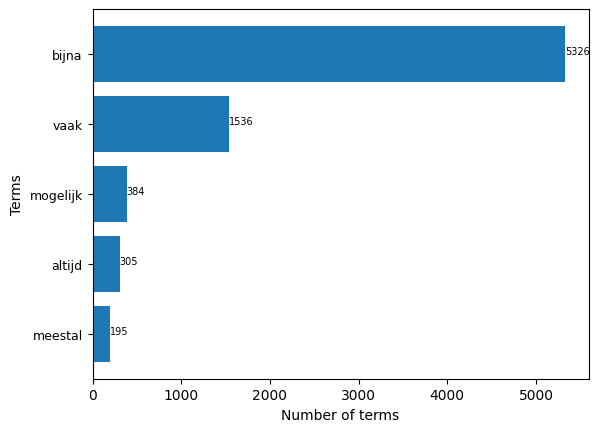

In [6]:
import matplotlib.pyplot as plt
y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())

import matplotlib.pyplot as plt
def addlabels(df_sorted):
    for i in range(len(df_sorted)):
        plt.text(df_sorted.iloc[i]["freq"] + 0.1,i, str(df_sorted.iloc[i]["freq"]), fontsize = 7)


df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
df_sorted = df_sorted.tail(5)
plt.barh(df_sorted["words"] ,df_sorted["freq"])
addlabels(df_sorted)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 9)
plt.show()